# Успеваемость студентов (Student Performance)

## О данных (About Dataset)
Этот набор данных содержит данные об успеваемости 1000 учащихся по трём предметам: математике, чтению и письму. Он включает в себя профили учащихся и социально-экономическую информацию, что делает его идеальным для образовательных исследований, статистического анализа и задач машинного обучения, связанных с результатами учащихся.<br>
(This dataset consists of academic performance data for 1000 students across three subjects: **math, reading, and writing**. The dataset includes student profile and socio-economic details, making it ideal for educational research, statistical analysis, and machine learning tasks related to student outcomes)

#### Импортируем необходимые модули

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats

#### Загружаем данные

In [2]:
path = '../Datasets/StudentsPerformance.csv'

In [3]:
df = pd.read_csv(path)

In [4]:
df.head(5)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
df[df['test preparation course'] == 'none'].head(5)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78


#### Посмотрим общую информацию о датасете

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


##### Записей об успеваемости студентов действительно ровно одна тысяча. Стоблцы пола, обезличенные данные по этнической принадлежности, образовании родителей, питании и подготовительных курсах имеют строчный вид данных, столбцы math/reading/writing score представлены в целочисленном виде. Пропусков данных нет

#### Можно выполнить преобразования типов данных для ускорения выполнения кода (В конкретном небольшом датасете влияние будет малозаметно)

In [7]:
df['gender'] = df['gender'].astype('category')
df['race/ethnicity'] = df['race/ethnicity'].astype('category')
df['parental level of education'] = df['parental level of education'].astype('category')
df['lunch'] = df['lunch'].astype('category')
df['test preparation course'] = df['test preparation course'].astype('category')
df['math score'] = df['math score'].astype('uint8')
df['reading score'] = df['reading score'].astype('uint8')
df['writing score'] = df['writing score'].astype('uint8')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   gender                       1000 non-null   category
 1   race/ethnicity               1000 non-null   category
 2   parental level of education  1000 non-null   category
 3   lunch                        1000 non-null   category
 4   test preparation course      1000 non-null   category
 5   math score                   1000 non-null   uint8   
 6   reading score                1000 non-null   uint8   
 7   writing score                1000 non-null   uint8   
dtypes: category(5), uint8(3)
memory usage: 8.7 KB


#### Количество уникальных значений в каждом столбце

In [9]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

## Анализ успеваемости

#### Найдем студентов с наивысшими баллами хотя бы по одному предмету

In [10]:
print('Всего студентов с наивысшими оценками: ', len(df[(df['math score'] == 100) | (df['reading score'] == 100) | (df['writing score'] == 100)]))
df[(df['math score'] == 100) | (df['reading score'] == 100) | (df['writing score'] == 100)].head(5)

Всего студентов с наивысшими оценками:  23


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
106,female,group D,master's degree,standard,none,87,100,100
114,female,group E,bachelor's degree,standard,completed,99,100,100
149,male,group E,associate's degree,free/reduced,completed,100,100,93
165,female,group C,bachelor's degree,standard,completed,96,100,100
179,female,group D,some high school,standard,completed,97,100,100


#### Найдем студентов у которых 100 баллов по всем предметам:

In [11]:
print ('Всего "стобальников": ', len(df[(df['math score'] == 100) & (df['reading score'] == 100) & (df['writing score'] == 100)]))
df[(df['math score'] == 100) & (df['reading score'] == 100) & (df['writing score'] == 100)]

Всего "стобальников":  3


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
458,female,group E,bachelor's degree,standard,none,100,100,100
916,male,group E,bachelor's degree,standard,completed,100,100,100
962,female,group E,associate's degree,standard,none,100,100,100


#### Найдем студентов с наихудшей успеваемостью (имееет по одному из предметов 0 баллов):

In [12]:
print ('Имеют 0 баллов: ', len(df[(df['math score'] == 0) | (df['reading score'] == 0) | (df['writing score'] == 0)]))
df[(df['math score'] == 0) | (df['reading score'] == 0) | (df['writing score'] == 0)]

Имеют 0 баллов:  1


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
59,female,group C,some high school,free/reduced,none,0,17,10




### Получим распределение средней оценки группам и полу

In [32]:
avgscore_df = df.groupby(['gender', 'race/ethnicity'], observed=True).agg(
    math_avg=('math score', 'mean'),
    reading_avg=('reading score', 'mean'),
    writing_avg=('writing score', 'mean')
).round().astype(int).reset_index()

In [31]:
avgscore_df

,gender,race/ethnicity,math_avg,reading_avg,writing_avg
0,female,group A,59,69,68
1,female,group B,61,71,70
2,female,group C,62,72,72
3,female,group D,65,74,75
4,female,group E,71,76,76
5,male,group A,64,62,59
6,male,group B,66,63,60
7,male,group C,68,65,63
8,male,group D,69,66,65
9,male,group E,77,70,67


#### Добавим столбец средней оценки по группам

In [15]:
avgscore_df['overall_avg'] = avgscore_df[['math_avg', 'reading_avg', 'writing_avg']].mean(axis=1).round().astype(int)

In [16]:
avgscore_df

,gender,race/ethnicity,math_avg,reading_avg,writing_avg,overall_avg
0,female,group A,59,69,68,65
1,female,group B,61,71,70,67
2,female,group C,62,72,72,69
3,female,group D,65,74,75,71
4,female,group E,71,76,76,74
5,male,group A,64,62,59,62
6,male,group B,66,63,60,63
7,male,group C,68,65,63,65
8,male,group D,69,66,65,67
9,male,group E,77,70,67,71


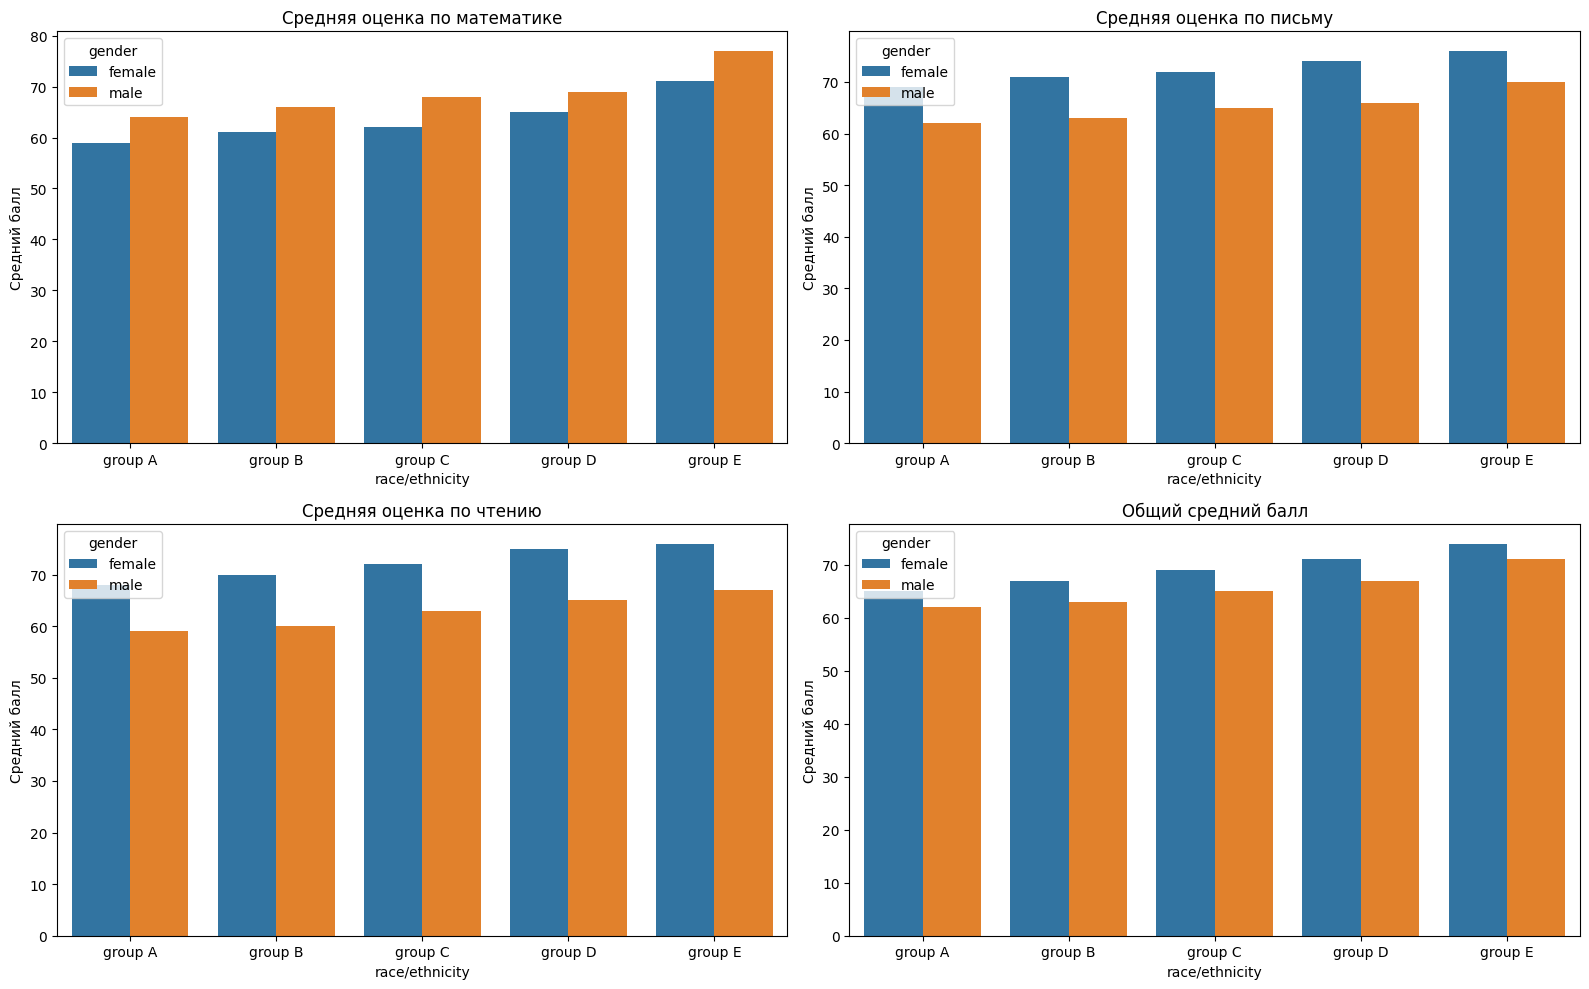

In [17]:
plt.figure(figsize=(16, 10))

plt.subplot(2, 2, 1)
sns.barplot(avgscore_df, x = 'race/ethnicity', y = 'math_avg', hue = 'gender')
plt.title('Средняя оценка по математике')
plt.ylabel('Средний балл')

plt.subplot(2, 2, 2)
sns.barplot(avgscore_df, x = 'race/ethnicity', y = 'reading_avg', hue = 'gender')
plt.title('Средняя оценка по письму')
plt.ylabel('Средний балл')

plt.subplot(2, 2, 3)
sns.barplot(avgscore_df, x = 'race/ethnicity', y = 'writing_avg', hue = 'gender')
plt.title('Средняя оценка по чтению')
plt.ylabel('Средний балл')

plt.subplot(2, 2, 4)
sns.barplot(avgscore_df, x = 'race/ethnicity', y = 'overall_avg', hue = 'gender')
plt.title('Общий средний балл')
plt.ylabel('Средний балл')

plt.tight_layout()
plt.show()

# Проверка статистических гипотез

## 1. Н0 - есть статистические различия успеваемости в группе А между студентами и студентками

### 1.1. Различия успеваемости по математике

#### Выборка групп:

In [18]:
group_A = df[(df['gender'] == 'female') & (df['race/ethnicity'] == 'group A')]['math score']
group_B = df[(df['gender'] == 'male') & (df['race/ethnicity'] == 'group A')]['math score']

#### Тест на нормальность Шапиро-Вилка/Shapiro-Wilk test for normality

In [35]:
shapiro_A = stats.shapiro(group_A)
shapiro_B = stats.shapiro(group_B)
print("Shapiro A p =", shapiro_A.pvalue)
if shapiro_A.pvalue > 0.05:
    print ('- распределение близко к нормальному')
else:
    print('- не нормальное распределение')
print("Shapiro B p =", shapiro_B.pvalue)
if shapiro_B.pvalue > 0.05:
    print ('- распределение близко к нормальному')
else:
    print('- не нормальное распределение')

Shapiro A p = 0.6523340671666013
- распределение близко к нормальному
Shapiro B p = 0.9547782278704576
- распределение близко к нормальному


Распределение довольно близко к нормальному. Оценим визуально с использование Q-Q plot (quantile-quantile)

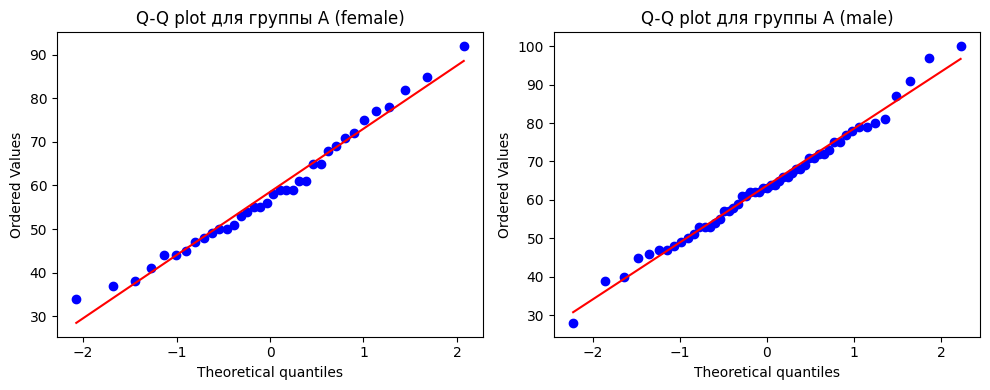

In [20]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
stats.probplot(group_A, dist="norm", plot=plt)
plt.title("Q-Q plot для группы A (female)")

plt.subplot(1, 2, 2)
stats.probplot(group_B, dist="norm", plot=plt)
plt.title("Q-Q plot для группы A (male)")

plt.tight_layout()
plt.show()

Точки вдоль прямой линии с небольшим отклонением на концах — нормальность «достаточная».

Проведем еще одну визульную оценку.

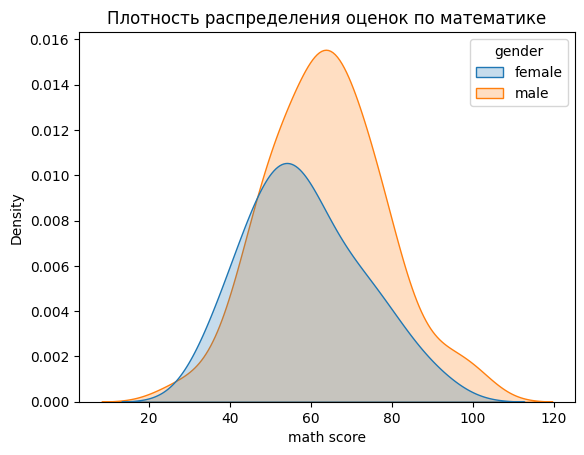

In [21]:
sns.kdeplot(data=df[(df['race/ethnicity'] == 'group A')], x='math score', hue='gender', fill=True)
plt.title('Плотность распределения оценок по математике')
plt.show()

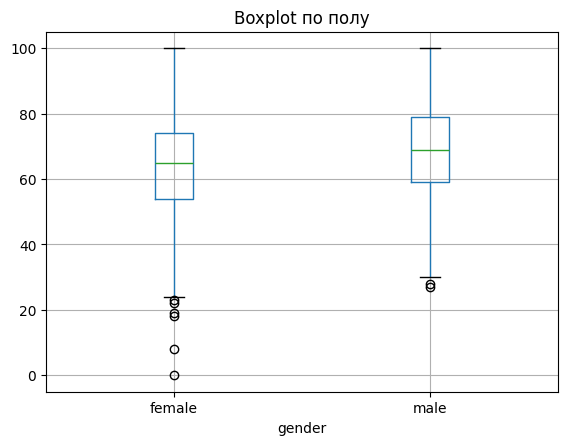

In [22]:
df.boxplot(column='math score', by='gender')
plt.suptitle('')
plt.title('Boxplot по полу')
plt.show()

Очевидно, что номальность присутствует в распределении с незначительными отклонениями

## Проверка равенства дисперсий 

In [23]:
# Levene's test (устойчив к отклонениям от нормальности)
w_stat, p_levene = stats.levene(group_A, group_B)
print(f"Levene's test p = {p_levene:.4f}")
# Если p < 0.05 → дисперсии **неравны** → точно нужен Welch’s.

Levene's test p = 0.9902


Дисперсии групп близки. Можно провести стандартный t-тест. Дополнительно можно провести Welch’s t-test (применяется при различных дисперсиях)

## T-test + T-test (Welch)

In [24]:
t_student, p_student = stats.ttest_ind(group_A, group_B, equal_var=True)
t_welch, p_welch = stats.ttest_ind(group_A, group_B, equal_var=False)

print(f"Student's t-test:  t = {t_student:.3f}, p = {p_student:.4f}")
if p_student < 0.05:
    print("Различия статистически значимы.")
else:
    print("Статистически значимых различий нет.")
print(f"Welch's t-test:    t = {t_welch:.3f}, p = {p_welch:.4f}")
if p_welch < 0.05:
    print("Различия статистически значимы.")
else:
    print("Статистически значимых различий нет.")

Student's t-test:  t = -1.677, p = 0.0970
Статистически значимых различий нет.
Welch's t-test:    t = -1.686, p = 0.0959
Статистически значимых различий нет.


Добавим еще один тест Mann-Whitney U test (не требует нормального распределения и устойчив к выбросам, однако не такой мощный как t-test)

## Mann-Whitney U test

In [25]:
# Mann-Whitney U test (непараметрический)
u, p = stats.mannwhitneyu(group_A, group_B, alternative='two-sided')
print(f"Mann-Whitney U test: p = {p:.4f}")

if p < 0.05:
    print("Различия статистически значимы.")
else:
    print("Статистически значимых различий нет.")

Mann-Whitney U test: p = 0.0791
Статистически значимых различий нет.


#### Вывод: Различия в упеваемости по математике между студентами и студентками в группе А не яляются статистически значимыми (α = 0.05)

### 1.2. Различия успеваемости по чтению

In [37]:
group_A = df[(df['gender'] == 'female') & (df['race/ethnicity'] == 'group A')]['reading score']
group_B = df[(df['gender'] == 'male') & (df['race/ethnicity'] == 'group A')]['reading score']
shapiro_A = stats.shapiro(group_A)
shapiro_B = stats.shapiro(group_B)
print("Shapiro A p =", shapiro_A.pvalue)
if shapiro_A.pvalue > 0.05:
    print ('- распределение близко к нормальному')
else:
    print('- не нормальное распределение')
print("Shapiro B p =", shapiro_B.pvalue)
if shapiro_B.pvalue > 0.05:
    print ('- распределение близко к нормальному')
else:
    print('- не нормальное распределение')

Shapiro A p = 0.5536471127732417
- распределение близко к нормальному
Shapiro B p = 0.9430361921317141
- распределение близко к нормальному


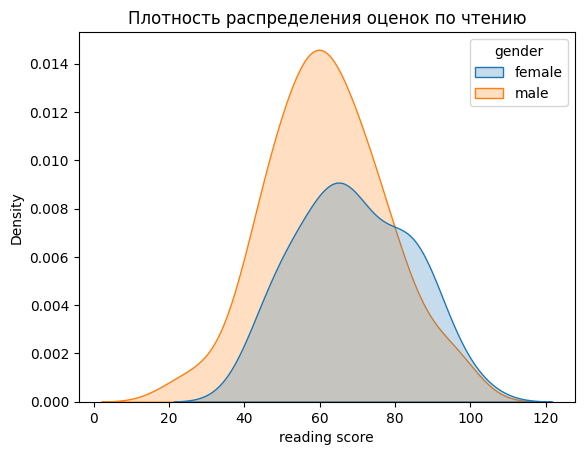

In [39]:
sns.kdeplot(data=df[(df['race/ethnicity'] == 'group A')], x='reading score', hue='gender', fill=True)
plt.title('Плотность распределения оценок по чтению')
plt.show()

In [40]:
# Levene's test (устойчив к отклонениям от нормальности)
w_stat, p_levene = stats.levene(group_A, group_B)
print(f"Levene's test p = {p_levene:.4f}")
# Если p < 0.05 → дисперсии **неравны** → точно нужен Welch’s.

t_student, p_student = stats.ttest_ind(group_A, group_B, equal_var=True)
t_welch, p_welch = stats.ttest_ind(group_A, group_B, equal_var=False)

print(f"Student's t-test:  t = {t_student:.3f}, p = {p_student:.4f}")
if p_student < 0.05:
    print("Различия статистически значимы.")
else:
    print("Статистически значимых различий нет.")
print(f"Welch's t-test:    t = {t_welch:.3f}, p = {p_welch:.4f}")
if p_welch < 0.05:
    print("Различия статистически значимы.")
else:
    print("Статистически значимых различий нет.")
# Mann-Whitney U test (непараметрический)
u, p = stats.mannwhitneyu(group_A, group_B, alternative='two-sided')
print(f"Mann-Whitney U test: p = {p:.4f}")

if p < 0.05:
    print("Различия статистически значимы.")
else:
    print("Статистически значимых различий нет.")

Levene's test p = 0.9178
Student's t-test:  t = 2.211, p = 0.0296
Различия статистически значимы.
Welch's t-test:    t = 2.228, p = 0.0288
Различия статистически значимы.
Mann-Whitney U test: p = 0.0377
Различия статистически значимы.


#### Вывод: Различия в упеваемости по чтению между студентами и студентками в группе А являются статистически значимыми (α = 0.05)

### 1.3. Различия успеваемости по письму

In [42]:
group_A = df[(df['gender'] == 'female') & (df['race/ethnicity'] == 'group A')]['writing score']
group_B = df[(df['gender'] == 'male') & (df['race/ethnicity'] == 'group A')]['writing score']
shapiro_A = stats.shapiro(group_A)
shapiro_B = stats.shapiro(group_B)
print("Shapiro A p =", shapiro_A.pvalue)
if shapiro_A.pvalue > 0.05:
    print ('- распределение близко к нормальному')
else:
    print('- не нормальное распределение')
print("Shapiro B p =", shapiro_B.pvalue)
if shapiro_B.pvalue > 0.05:
    print ('- распределение близко к нормальному')
else:
    print('- не нормальное распределение')

Shapiro A p = 0.8216986381195888
- распределение близко к нормальному
Shapiro B p = 0.6918718915671099
- распределение близко к нормальному


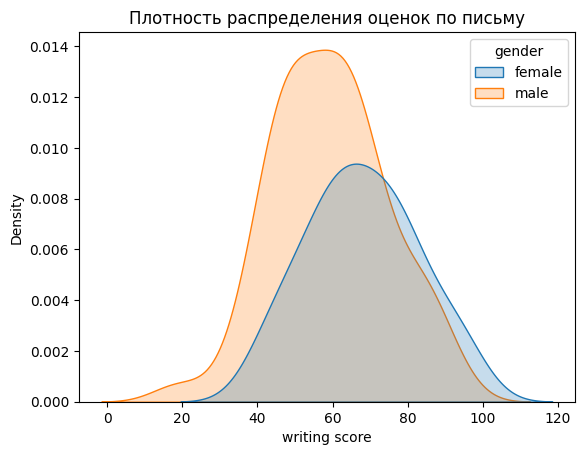

In [44]:
sns.kdeplot(data=df[(df['race/ethnicity'] == 'group A')], x='writing score', hue='gender', fill=True)
plt.title('Плотность распределения оценок по письму')
plt.show()

In [45]:
# Levene's test (устойчив к отклонениям от нормальности)
w_stat, p_levene = stats.levene(group_A, group_B)
print(f"Levene's test p = {p_levene:.4f}")
# Если p < 0.05 → дисперсии **неравны** → точно нужен Welch’s.

t_student, p_student = stats.ttest_ind(group_A, group_B, equal_var=True)
t_welch, p_welch = stats.ttest_ind(group_A, group_B, equal_var=False)

print(f"Student's t-test:  t = {t_student:.3f}, p = {p_student:.4f}")
if p_student < 0.05:
    print("Различия статистически значимы.")
else:
    print("Статистически значимых различий нет.")
print(f"Welch's t-test:    t = {t_welch:.3f}, p = {p_welch:.4f}")
if p_welch < 0.05:
    print("Различия статистически значимы.")
else:
    print("Статистически значимых различий нет.")
# Mann-Whitney U test (непараметрический)
u, p = stats.mannwhitneyu(group_A, group_B, alternative='two-sided')
print(f"Mann-Whitney U test: p = {p:.4f}")

if p < 0.05:
    print("Различия статистически значимы.")
else:
    print("Статистически значимых различий нет.")

Levene's test p = 0.8927
Student's t-test:  t = 2.699, p = 0.0084
Различия статистически значимы.
Welch's t-test:    t = 2.716, p = 0.0082
Различия статистически значимы.
Mann-Whitney U test: p = 0.0113
Различия статистически значимы.


#### Вывод: Различия в упеваемости по письму между студентами и студентками в группе А являются статистически значимыми (α = 0.05)

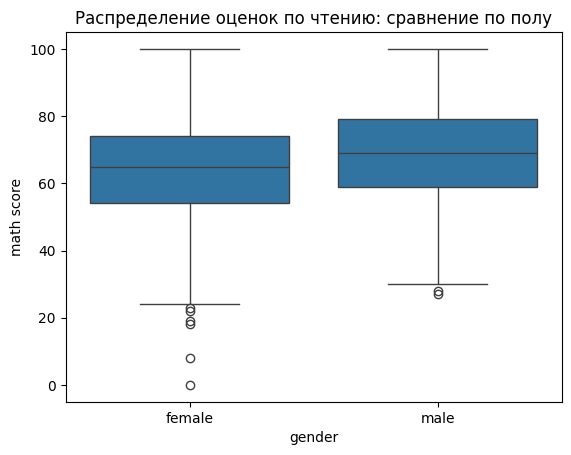

In [28]:
sns.boxplot(data=df, x='gender', y='math score')
plt.title('Распределение оценок по чтению: сравнение по полу')
plt.show()

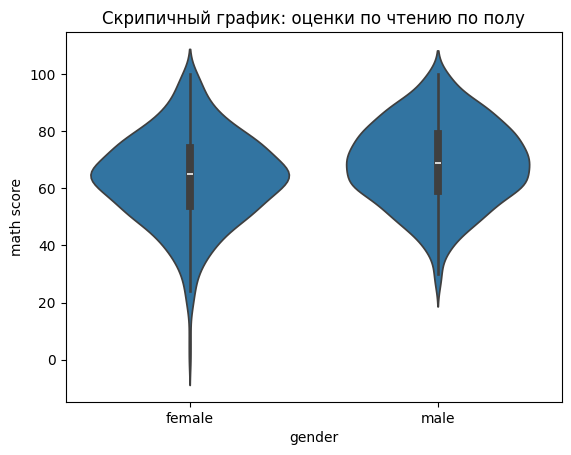

In [29]:
sns.violinplot(data=df, x='gender', y='math score', inner='box')
plt.title('Скрипичный график: оценки по чтению по полу')
plt.show()